[*********************100%***********************]  1 of 1 completed


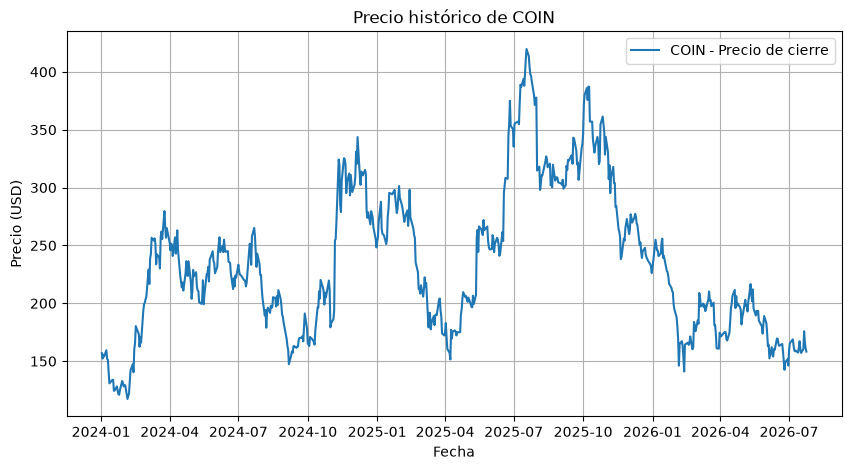

In [4]:
import yfinance as yf
import matplotlib.pyplot as plt

# Descargar datos históricos, ej. Coinbase (COIN)
data = yf.download("COIN", start="2024-01-01", end="2026-07-26")

# Graficar el precio de cierre
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Close"], label="COIN - Precio de cierre")
plt.title("Precio histórico de COIN")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Retornos diarios y volatilidad anualizada
data["Retorno"] = data["Close"].pct_change()
volatilidad_anual = data["Retorno"].std() * (252 ** 0.5)
print(f"Volatilidad anualizada: {volatilidad_anual:.2%}")


Volatilidad anualizada: 78.51%


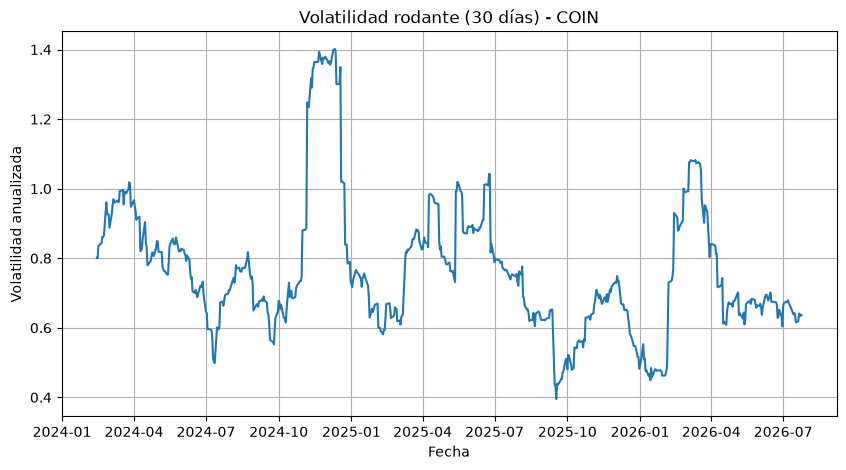

Máximo drawdown: -66.39%


In [6]:
# Volatilidad móvil de 30 días, anualizada
data["Vol_30d"] = data["Retorno"].rolling(window=30).std() * (252 ** 0.5)

plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Vol_30d"])
plt.title("Volatilidad rodante (30 días) - COIN")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad anualizada")
plt.grid(True)
plt.show()
acumulado = (1 + data["Retorno"]).cumprod()
maximo_historico = acumulado.cummax()
drawdown = (acumulado - maximo_historico) / maximo_historico

max_drawdown = drawdown.min()
print(f"Máximo drawdown: {max_drawdown:.2%}")